In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [15]:
#basic info
print("== DATASET INFO ==")
print(df.info())

print("\n== BASIC STATISTICS ==")
print(df.describe())

print("\n == MISSING VALUES ==")
print(df.isnull().sum())
print(f"\n Missing CustomerID: {df['CustomerID'].isnull().sum()} rows ({df['CustomerID'].isnull().mean()*100:.1f}%)")

== DATASET INFO ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

== BASIC STATISTICS ==
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152

In [16]:
# Check for cancellations (InvoiceNo starting with 'C')
cancellations = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Cancelled transactions: {len(cancellations)} ({len(cancellations)/len(df)*100:.1f}%)")

# Check for negative quantities
print(f"Negative quantities: {(df['Quantity'] < 0).sum()}")

# Check for zero/negative prices
print(f"Zero or negative prices: {(df['UnitPrice'] <= 0).sum()}")

# Check date range
print(f"\nDate range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

# Check number of unique customers
print(f"Unique customers: {df['CustomerID'].nunique()}")

# Check number of unique countries
print(f"Unique countries: {df['Country'].nunique()}")
print(df['Country'].value_counts().head(10))

Cancelled transactions: 9288 (1.7%)
Negative quantities: 10624
Zero or negative prices: 2517

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4372
Unique countries: 38
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


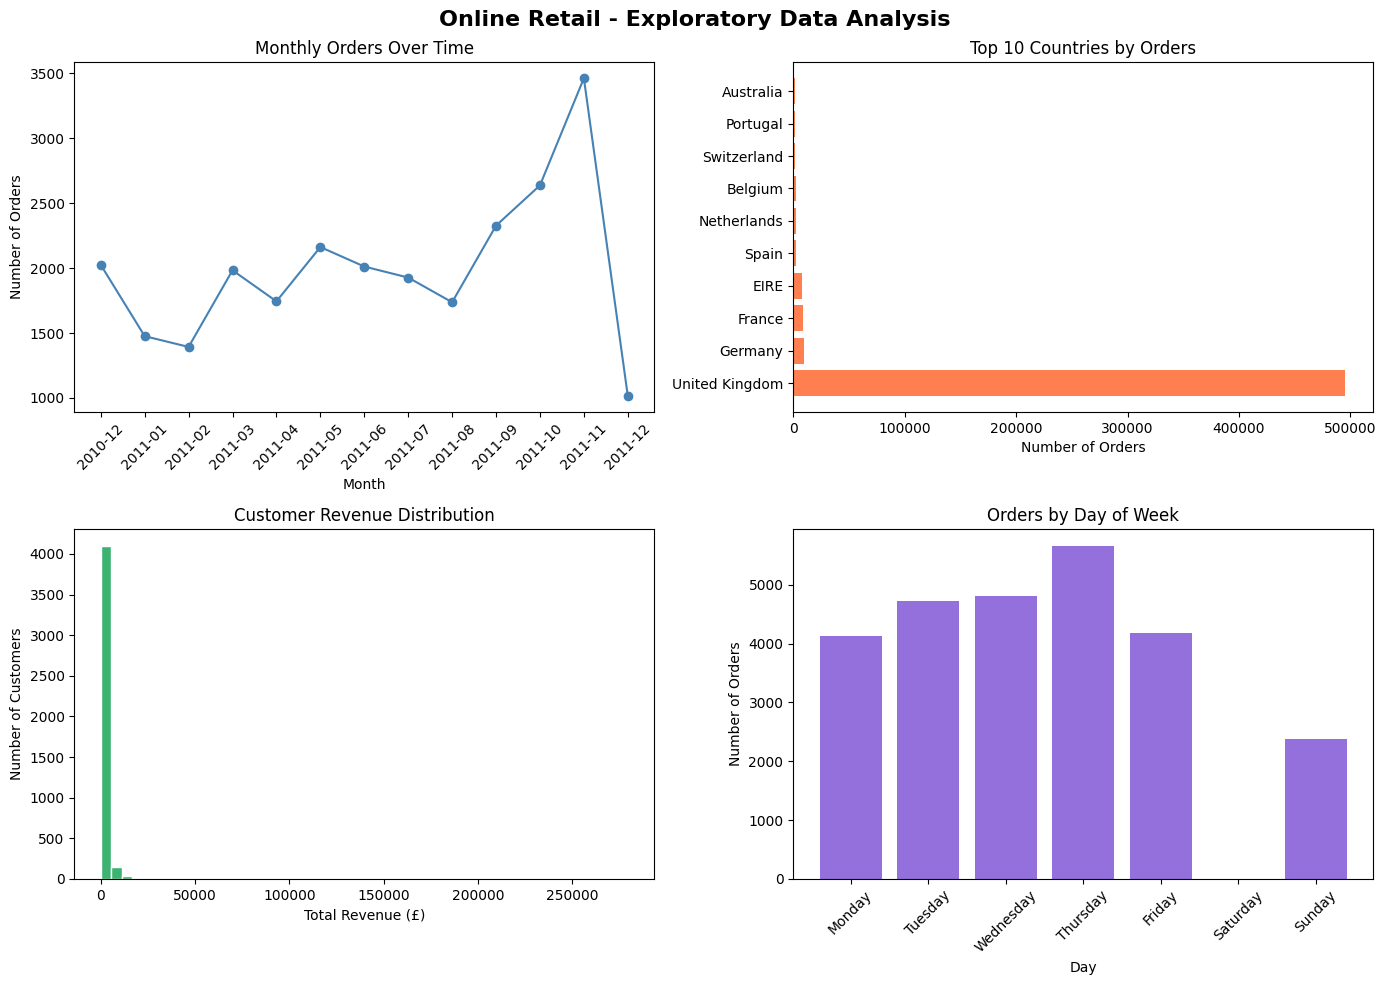

In [26]:
import matplotlib.pyplot as plt

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Online Retail - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Flatten axes into 1D array for easy indexing
axes = axes.flatten()

# Convert InvoiceDate column to datetime 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# 1. Orders over time
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_orders = df.groupby('YearMonth')['InvoiceNo'].nunique()
x_values = monthly_orders.index.astype(str)

axes[0].plot(x_values, monthly_orders.values, marker='o', color='steelblue')
axes[0].set_title('Monthly Orders Over Time')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=45)

# 2. Top 10 countries by orders
top_countries = df['Country'].value_counts().head(10)
axes[1].barh(top_countries.index, top_countries.values, color='coral')
axes[1].set_title('Top 10 Countries by Orders')
axes[1].set_xlabel('Number of Orders')

# 3. Revenue distribution
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
customer_revenue = df.groupby('CustomerID')['TotalPrice'].sum()
axes[2].hist(customer_revenue[customer_revenue > 0], bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Customer Revenue Distribution')
axes[2].set_xlabel('Total Revenue (£)')
axes[2].set_ylabel('Number of Customers')

# 4. Orders by day of week
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df.groupby('DayOfWeek')['InvoiceNo'].nunique().reindex(day_order)
axes[3].bar(day_counts.index, day_counts.values, color='mediumpurple')
axes[3].set_title('Orders by Day of Week')
axes[3].set_xlabel('Day')
axes[3].set_ylabel('Number of Orders')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### DATA CLEANING

In [27]:
print(f"Original shape: {df.shape}")

# 1. Remove rows with missing CustomerID
df_clean = df.dropna(subset=['CustomerID'])

# 2. Remove cancellations
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove negative or zero quantities
df_clean = df_clean[df_clean['Quantity'] > 0]

# 4. Remove zero or negative prices
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# 5. Convert CustomerID to integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 6. Ensure InvoiceDate is datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 7. Keep only UK customers (largest segment - keeps data consistent)
df_clean = df_clean[df_clean['Country'] == 'United Kingdom']

# 8. Recalculate TotalPrice on clean data
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Cleaned shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")
print(f"\nUnique customers after cleaning: {df_clean['CustomerID'].nunique()}")
print(f"Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")

Original shape: (541909, 11)
Cleaned shape: (354321, 11)
Rows removed: 187588

Unique customers after cleaning: 3920
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:49:00


In [28]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354321 entries, 0 to 541893
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    354321 non-null  object        
 1   StockCode    354321 non-null  object        
 2   Description  354321 non-null  object        
 3   Quantity     354321 non-null  int64         
 4   InvoiceDate  354321 non-null  datetime64[ns]
 5   UnitPrice    354321 non-null  float64       
 6   CustomerID   354321 non-null  int32         
 7   Country      354321 non-null  object        
 8   YearMonth    354321 non-null  period[M]     
 9   TotalPrice   354321 non-null  float64       
 10  DayOfWeek    354321 non-null  object        
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(5), period[M](1)
memory usage: 31.1+ MB


### RFM Feature Enginnering

In [37]:
# The "today" reference point for calculating recency
# We use 1 day after the last transaction in the dataset

snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

Snapshot date: 2011-12-10 12:49:00


In [38]:
# Build RFM table — one row per customer
rfm = df_clean.groupby('CustomerID').agg(
    last_purchase   = ('InvoiceDate', 'max'),       # most recent purchase date
    frequency       = ('InvoiceNo', 'nunique'),      # number of unique invoices
    monetary        = ('TotalPrice', 'mean'),        # average order value
    total_revenue   = ('TotalPrice', 'sum')          # total revenue (for reference)
).reset_index()

# Calculate recency in days
rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

# Drop the raw date column
rfm.drop(columns=['last_purchase'], inplace=True)

# Reorder columns nicely
rfm = rfm[['CustomerID', 'recency', 'frequency', 'monetary', 'total_revenue']]

print(f"RFM Table Shape: {rfm.shape}")
print(f"\nFirst 5 rows:")
rfm.head()

RFM Table Shape: (3920, 5)

First 5 rows:


,CustomerID,recency,frequency,monetary,total_revenue
0,12346,326,1,77183.600000,77183.60
1,12747,2,11,40.737961,4196.01
2,12748,1,209,7.338353,33719.73
3,12749,4,5,20.557186,4090.88
4,12820,3,4,15.971864,942.34


In [39]:
print("=== RFM STATISTICS ===")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

=== RFM STATISTICS ===
       recency  frequency  monetary
count  3920.00    3920.00   3920.00
mean     92.21       4.25     71.76
std      99.53       7.20   1543.98
min       1.00       1.00      2.10
25%      18.00       1.00     11.19
50%      51.00       2.00     17.28
75%     143.00       5.00     24.39
max     374.00     209.00  77183.60


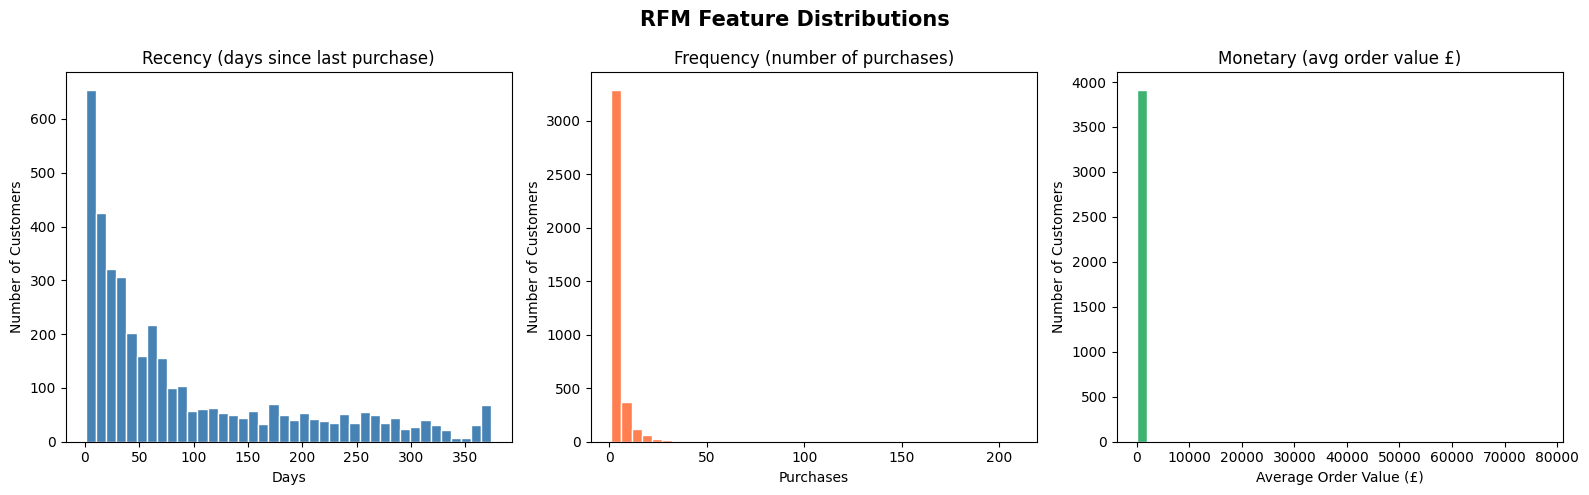

In [40]:
# Visualize RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Feature Distributions', fontsize=15, fontweight='bold')

# Recency
axes[0].hist(rfm['recency'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Recency (days since last purchase)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Customers')

# Frequency
axes[1].hist(rfm['frequency'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Frequency (number of purchases)')
axes[1].set_xlabel('Purchases')
axes[1].set_ylabel('Number of Customers')

# Monetary
axes[2].hist(rfm['monetary'], bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Monetary (avg order value £)')
axes[2].set_xlabel('Average Order Value (£)')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### RFM Scoring(Ranking Customers 1-5)

In [41]:
# Score Recency: LOWER recency = BETTER = score 5
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])

# Score Frequency: HIGHER frequency = BETTER = score 5
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Score Monetary: HIGHER monetary = BETTER = score 5
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Convert to integer
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# Combine into one RFM score
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# Overall score (average)
rfm['RFM_total'] = (rfm['R_score'] + rfm['F_score'] + rfm['M_score']) / 3

print(rfm[['CustomerID', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_total']].head(10))

   CustomerID  recency  frequency      monetary  R_score  F_score  M_score  \
0       12346      326          1  77183.600000        1        1        5   
1       12747        2         11     40.737961        5        5        5   
2       12748        1        209      7.338353        5        5        1   
3       12749        4          5     20.557186        5        4        4   
4       12820        3          4     15.971864        5        4        3   
5       12821      214          1     15.453333        1        1        2   
6       12822       71          2     20.627826        3        2        4   
7       12823       75          5    351.900000        2        4        5   
8       12824       60          1     15.884800        3        1        3   
9       12826        3          7     16.205714        5        5        3   

  RFM_score  RFM_total  
0       115   2.333333  
1       555   5.000000  
2       551   3.666667  
3       544   4.333333  
4       543   4.

### Segementing Customers


In [42]:
# Define segments based on RFM total score
def segment_customer(score):
    if score >= 4.5:
        return 'Champions'
    elif score >= 3.5:
        return 'Loyal Customers'
    elif score >= 2.5:
        return 'Potential Loyalists'
    elif score >= 1.5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_total'].apply(segment_customer)

# See segment breakdown
segment_counts = rfm['Segment'].value_counts()
print("=== CUSTOMER SEGMENTS ===")
print(segment_counts)

=== CUSTOMER SEGMENTS ===
Segment
Potential Loyalists    1408
At Risk                1061
Loyal Customers         977
Champions               266
Lost                    208
Name: count, dtype: int64


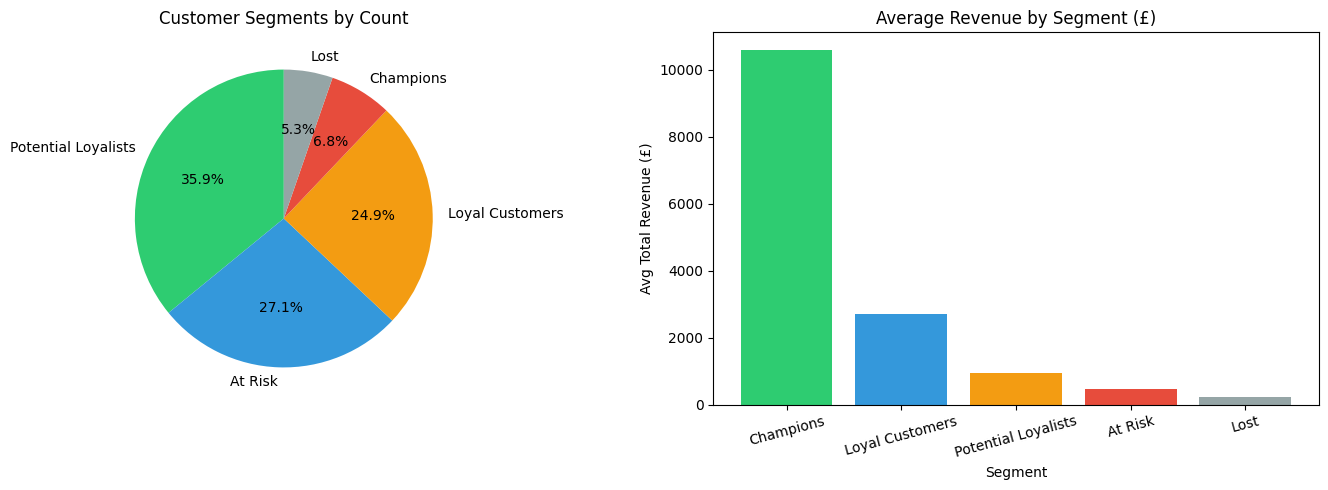

In [43]:
# Visualize segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart - customer count per segment
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
axes[0].pie(segment_counts.values, labels=segment_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Customer Segments by Count')

# Bar chart - average revenue per segment
segment_revenue = rfm.groupby('Segment')['total_revenue'].mean().sort_values(ascending=False)
axes[1].bar(segment_revenue.index, segment_revenue.values, color=colors)
axes[1].set_title('Average Revenue by Segment (£)')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Avg Total Revenue (£)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Saving my clean RFM Table


In [44]:
# Save for use in next stages
rfm.to_csv('rfm_table.csv', index=False)
print("✅ RFM table saved as rfm_table.csv")
print(f"Final shape: {rfm.shape}")

✅ RFM table saved as rfm_table.csv
Final shape: (3920, 11)


### Customer LifeTime Value Calculation
##### Part A: Historical CLV -> What has each customer already spent?
##### Part B: Predictive CLV -> What will each customer spend in the next 90 days?

In [45]:
#Part A
#Formula Used: Historical CLV = Total Revenue x Gross margin
# ---- HISTORICAL CLV ----
GROSS_MARGIN = 0.20  # assume 20% gross margin

rfm['historical_clv'] = rfm['total_revenue'] * GROSS_MARGIN

print("=== HISTORICAL CLV SUMMARY ===")
print(rfm['historical_clv'].describe().round(2))
print(f"\nTop 5 most valuable customers:")
print(rfm[['CustomerID', 'total_revenue', 'historical_clv']]\
      .sort_values('historical_clv', ascending=False).head())

=== HISTORICAL CLV SUMMARY ===
count     3920.00
mean       372.88
std       1496.56
min          0.75
25%         60.06
50%        130.46
75%        315.32
max      51931.46
Name: historical_clv, dtype: float64

Top 5 most valuable customers:
      CustomerID  total_revenue  historical_clv
3783       18102      259657.30       51931.460
3314       17450      194550.79       38910.158
2598       16446      168472.50       33694.500
3356       17511       91062.38       18212.476
2294       16029       81024.84       16204.968


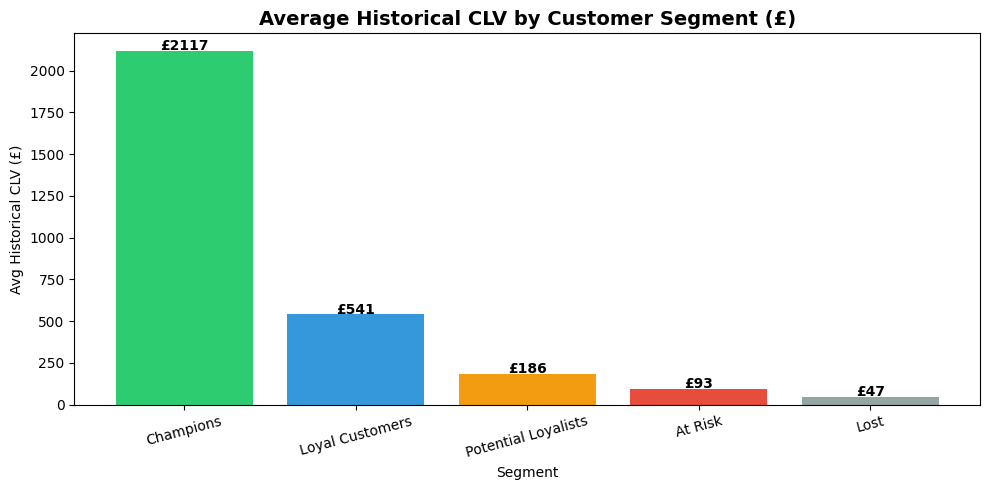

In [46]:
# Visualize Historical CLV by Segment
segment_clv = rfm.groupby('Segment')['historical_clv'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(segment_clv.index, segment_clv.values,
               color=['#2ecc71','#3498db','#f39c12','#e74c3c','#95a5a6'])
plt.title('Average Historical CLV by Customer Segment (£)', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Avg Historical CLV (£)')
plt.xticks(rotation=15)

# Add value labels on bars
for bar, val in zip(bars, segment_clv.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'£{val:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [51]:
#Part B Predictive CLV
#Using these two models:
#BG/NBD -> Predicts how many purchases a customer will make in the future
#Gamma-Gamma -> Predicts how much each purchase will be worth.

!pip install lifetimes

from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter

# Build the summary dataframe required by lifetimes
summary = summary_data_from_transaction_data(
    df_clean,
    customer_id_col='CustomerID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalPrice',
    observation_period_end=df_clean['InvoiceDate'].max()
)

print("=== LIFETIMES SUMMARY TABLE ===")
print(summary.head(10))
print(f"\nShape: {summary.shape}")

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/584.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/584.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/584.2 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/584.2 kB ? eta -:--:--
   ---------------------------------------- 584.2/584.2 kB 1.3 MB/s eta 0:00:00
=== LIFETIMES SUMMARY TABLE ===
            frequency  recency      T  monetary_value
CustomerID                                           
12346             0.0      0.0  325.0        0.000000
12747            10.0    367.0  369.0      383.745000
12748           112.0    373.0  373.0      301.024821
12749             3.0    210.0  213.0     1077.260000
12820             3.0    323.0  326.0      257.293333
12821             0.0      0.0  214.0        0.000000
12822             1.0     17.0   87.0      257.980000
12823             4.0    222.0  296.0 

In [52]:
#filtering for valid customers
# BG/NBD requires:
# - monetary_value > 0
# - frequency > 0 (at least one repeat purchase)

summary_filtered = summary[
    (summary['monetary_value'] > 0) &
    (summary['frequency'] > 0)
].copy()

print(f"Customers before filter: {len(summary)}")
print(f"Customers after filter:  {len(summary_filtered)}")
print(f"\nFiltered summary stats:")
print(summary_filtered.describe().round(2))

Customers before filter: 3920
Customers after filter:  2522

Filtered summary stats:
       frequency  recency        T  monetary_value
count    2522.00  2522.00  2522.00         2522.00
mean        4.43   204.15   260.90          455.57
std         6.61   111.35   101.62         3399.10
min         1.00     1.00     9.00            1.00
25%         1.00   107.00   201.00          183.71
50%         3.00   212.50   284.00          303.55
75%         5.00   301.00   358.00          437.84
max       112.00   373.00   373.00       168469.60


In [53]:
# ---- FIT BG/NBD MODEL ----
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(
    summary_filtered['frequency'],
    summary_filtered['recency'],
    summary_filtered['T']
)

print("✅ BG/NBD Model fitted successfully!")
print(bgf)

✅ BG/NBD Model fitted successfully!
<lifetimes.BetaGeoFitter: fitted with 2522 subjects, a: 0.01, alpha: 110.13, b: 0.19, r: 1.95>


In [54]:
# Predict purchases in next 90 days for each customer
summary_filtered['predicted_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t=90,  # 90 days
    frequency=summary_filtered['frequency'],
    recency=summary_filtered['recency'],
    T=summary_filtered['T']
)

print("\nPredicted purchases in next 90 days:")
print(summary_filtered[['frequency', 'recency', 'T', 'predicted_purchases_90d']].head(10).round(3))


Predicted purchases in next 90 days:
            frequency  recency      T  predicted_purchases_90d
CustomerID                                                    
12747            10.0    367.0  369.0                    2.240
12748           112.0    373.0  373.0                   21.207
12749             3.0    210.0  213.0                    1.370
12820             3.0    323.0  326.0                    1.016
12822             1.0     17.0   87.0                    1.127
12823             4.0    222.0  296.0                    1.304
12826             6.0    363.0  365.0                    1.502
12827             2.0     39.0   44.0                    2.275
12828             5.0    128.0  130.0                    2.593
12829             1.0     24.0  360.0                    0.181


In [55]:
# ---- FIT GAMMA-GAMMA MODEL ----
ggf = GammaGammaFitter(penalizer_coef=0.0)
ggf.fit(
    summary_filtered['frequency'],
    summary_filtered['monetary_value']
)

print("✅ Gamma-Gamma Model fitted successfully!")
print(ggf)

✅ Gamma-Gamma Model fitted successfully!
<lifetimes.GammaGammaFitter: fitted with 2522 subjects, p: 2.08, q: 3.79, v: 526.95>


In [56]:
# Predict expected average order value per customer
summary_filtered['predicted_avg_order_value'] = ggf.conditional_expected_average_profit(
    summary_filtered['frequency'],
    summary_filtered['monetary_value']
)

print("\nPredicted average order value:")
print(summary_filtered[['monetary_value', 'predicted_avg_order_value']].head(10).round(2))


Predicted average order value:
            monetary_value  predicted_avg_order_value
CustomerID                                           
12747               383.74                     384.79
12748               301.02                     302.11
12749              1077.26                     865.58
12820               257.29                     299.10
12822               257.98                     335.09
12823               363.38                     370.70
12826               219.95                     251.51
12827               106.20                     221.20
12828               158.34                     207.91
12829               207.25                     313.44


In [57]:
# ---- CALCULATE PREDICTED CLV ----
DISCOUNT_RATE = 0.01   # 1% monthly discount rate
TIME_HORIZON  = 3      # 3 months (≈ 90 days)
GROSS_MARGIN  = 0.20   # 20% gross margin

summary_filtered['predicted_clv_90d'] = ggf.customer_lifetime_value(
    bgf,
    summary_filtered['frequency'],
    summary_filtered['recency'],
    summary_filtered['T'],
    summary_filtered['monetary_value'],
    time=TIME_HORIZON,
    discount_rate=DISCOUNT_RATE,
    freq='D'
)

# Apply gross margin
summary_filtered['predicted_clv_90d'] = summary_filtered['predicted_clv_90d'] * GROSS_MARGIN

print("=== PREDICTED CLV (90 DAYS) SUMMARY ===")
print(summary_filtered['predicted_clv_90d'].describe().round(2))

=== PREDICTED CLV (90 DAYS) SUMMARY ===
count     2522.00
mean       134.56
std        387.57
min          7.01
25%         50.52
50%         78.86
75%        128.25
max      11295.98
Name: predicted_clv_90d, dtype: float64


In [58]:
# Merge predicted CLV back into our RFM table
final_df = rfm.merge(
    summary_filtered[['predicted_purchases_90d',
                       'predicted_avg_order_value',
                       'predicted_clv_90d']],
    on='CustomerID',
    how='left'
)

# Fill NaN (customers who didn't qualify for model)
final_df['predicted_clv_90d'].fillna(0, inplace=True)

print(f"Final dataframe shape: {final_df.shape}")
print(final_df[['CustomerID', 'Segment', 'historical_clv',
                 'predicted_clv_90d']].head(10).round(2))

Final dataframe shape: (3920, 15)
   CustomerID              Segment  historical_clv  predicted_clv_90d
0       12346              At Risk        15436.72               0.00
1       12747            Champions          839.20             169.01
2       12748      Loyal Customers         6743.95            1256.15
3       12749      Loyal Customers          818.18             232.48
4       12820      Loyal Customers          188.47              59.55
5       12821                 Lost           18.54               0.00
6       12822  Potential Loyalists          189.78              74.04
7       12823      Loyal Customers          351.90              94.74
8       12824              At Risk           79.42               0.00
9       12826      Loyal Customers          294.94              74.04


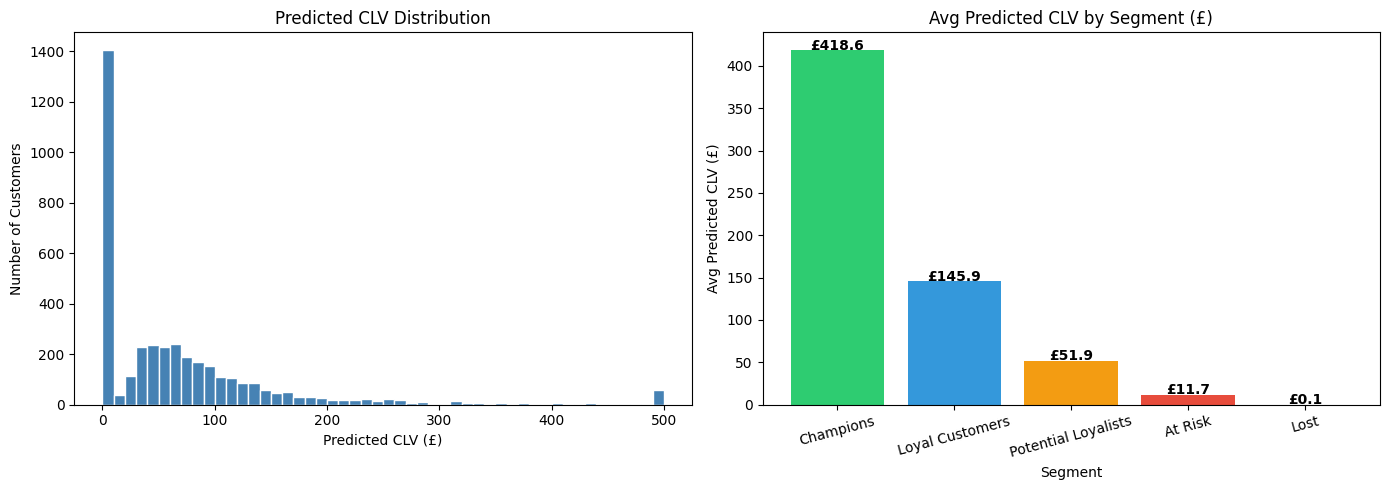

In [59]:
#visualizing predicted clv
ig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Predicted CLV — Next 90 Days', fontsize=15, fontweight='bold')

# Distribution of predicted CLV
axes[0].hist(final_df['predicted_clv_90d'].clip(upper=500),
             bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Predicted CLV Distribution')
axes[0].set_xlabel('Predicted CLV (£)')
axes[0].set_ylabel('Number of Customers')

# Predicted CLV by Segment
seg_pred_clv = final_df.groupby('Segment')['predicted_clv_90d']\
                        .mean().sort_values(ascending=False)
colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#95a5a6']
bars = axes[1].bar(seg_pred_clv.index, seg_pred_clv.values, color=colors)
axes[1].set_title('Avg Predicted CLV by Segment (£)')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Avg Predicted CLV (£)')
axes[1].tick_params(axis='x', rotation=15)

for bar, val in zip(bars, seg_pred_clv.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'£{val:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [60]:
#saving the final dataset
final_df.to_csv('clv_final.csv', index=False)
print("✅ Final CLV dataset saved as clv_final.csv")

# Quick business summary
print("\n=== BUSINESS SUMMARY ===")
print(f"Total customers analysed: {len(final_df):,}")
print(f"Total predicted revenue (90d): £{final_df['predicted_clv_90d'].sum():,.2f}")
print(f"Avg predicted CLV per customer: £{final_df['predicted_clv_90d'].mean():.2f}")
print(f"\nTop 10 most valuable customers (next 90 days):")
print(final_df[['CustomerID', 'Segment', 'predicted_clv_90d']]\
      .sort_values('predicted_clv_90d', ascending=False).head(10).round(2))

✅ Final CLV dataset saved as clv_final.csv

=== BUSINESS SUMMARY ===
Total customers analysed: 3,920
Total predicted revenue (90d): £339,371.19
Avg predicted CLV per customer: £86.57

Top 10 most valuable customers (next 90 days):
      CustomerID          Segment  predicted_clv_90d
2598       16446  Loyal Customers           11295.98
3783       18102        Champions            8852.32
3314       17450        Champions            7287.27
902        14096  Loyal Customers            5664.30
3356       17511        Champions            3344.50
2294       16029  Loyal Customers            2864.65
2766       16684        Champions            2593.16
620        13694        Champions            2401.67
1771       15311        Champions            2235.05
191        13089        Champions            2176.28


### Customer Segmentation with Machine Learning

In [61]:
# Select the features ML will use to group customers
features = [
    'recency',              # how recently they bought
    'frequency',            # how often they buy
    'monetary',             # avg order value
    'historical_clv',       # what they've spent
    'predicted_clv_90d'     # what they'll spend
]

# Create feature matrix
X = final_df[features].copy()

# Handle any missing values
X.fillna(0, inplace=True)

print("=== FEATURE MATRIX ===")
print(X.describe().round(2))
print(f"\nShape: {X.shape}")

=== FEATURE MATRIX ===
       recency  frequency  monetary  historical_clv  predicted_clv_90d
count  3920.00    3920.00   3920.00         3920.00            3920.00
mean     92.21       4.25     71.76          372.88              86.57
std      99.53       7.20   1543.98         1496.56             317.46
min       1.00       1.00      2.10            0.75               0.00
25%      18.00       1.00     11.19           60.06               0.00
50%      51.00       2.00     17.28          130.46              47.69
75%     143.00       5.00     24.39          315.32              95.33
max     374.00     209.00  77183.60        51931.46           11295.98

Shape: (3920, 5)


In [63]:
# Scale features to same range (mean=0, std=1)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features scaled successfully!")
print(f"\nBefore scaling - Recency mean: {X['recency'].mean():.1f}, std: {X['recency'].std():.1f}")
print(f"After scaling  - Recency mean: {X_scaled[:,0].mean():.4f}, std: {X_scaled[:,0].std():.4f}")

✅ Features scaled successfully!

Before scaling - Recency mean: 92.2, std: 99.5
After scaling  - Recency mean: -0.0000, std: 1.0000


In [64]:
#choosing number of clusters using elbow method and thier silhouette score
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"k={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={score:.4f}")

k=2: Inertia=13701, Silhouette=0.9648
k=3: Inertia=10298, Silhouette=0.9023
k=4: Inertia=7006, Silhouette=0.5616
k=5: Inertia=5243, Silhouette=0.5671
k=6: Inertia=4010, Silhouette=0.5853
k=7: Inertia=3204, Silhouette=0.5868
k=8: Inertia=2651, Silhouette=0.5844
k=9: Inertia=2243, Silhouette=0.4866
k=10: Inertia=1880, Silhouette=0.4645


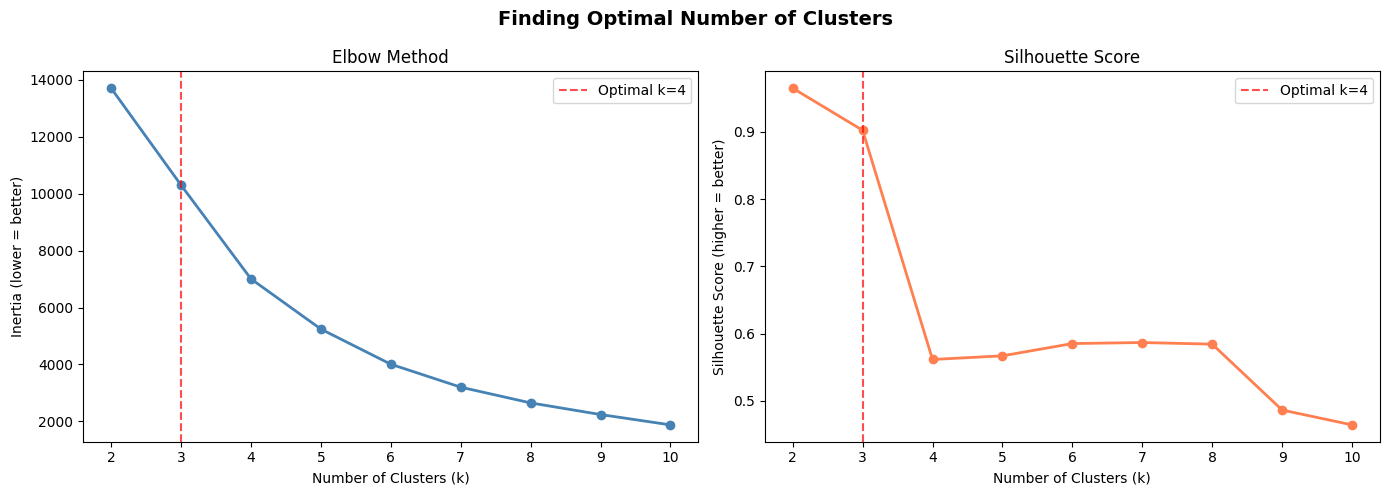

In [66]:
# Plot both methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finding Optimal Number of Clusters', fontsize=14, fontweight='bold')

# Elbow curve
axes[0].plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (lower = better)')
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Optimal k=4')
axes[0].legend()

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, marker='o', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Optimal k=4')
axes[1].legend()

plt.tight_layout()
plt.show()

In [67]:
# Fit with optimal k=3
OPTIMAL_K = 3

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
final_df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"✅ K-Means fitted with k={OPTIMAL_K}")
print(f"\nCluster distribution:")
print(final_df['cluster'].value_counts().sort_index())

✅ K-Means fitted with k=3

Cluster distribution:
cluster
0    3896
1       2
2      22
Name: count, dtype: int64


In [68]:
# Get the average values per cluster
cluster_profile = final_df.groupby('cluster')[features].mean().round(2)
print("=== CLUSTER PROFILES ===")
print(cluster_profile)

=== CLUSTER PROFILES ===
         recency  frequency  monetary  historical_clv  predicted_clv_90d
cluster                                                                 
0          92.66       3.92     36.91          288.17              69.88
1         163.50       1.50  66670.55        24565.61            5647.99
2           5.86      63.09    188.01        13174.61            2537.33


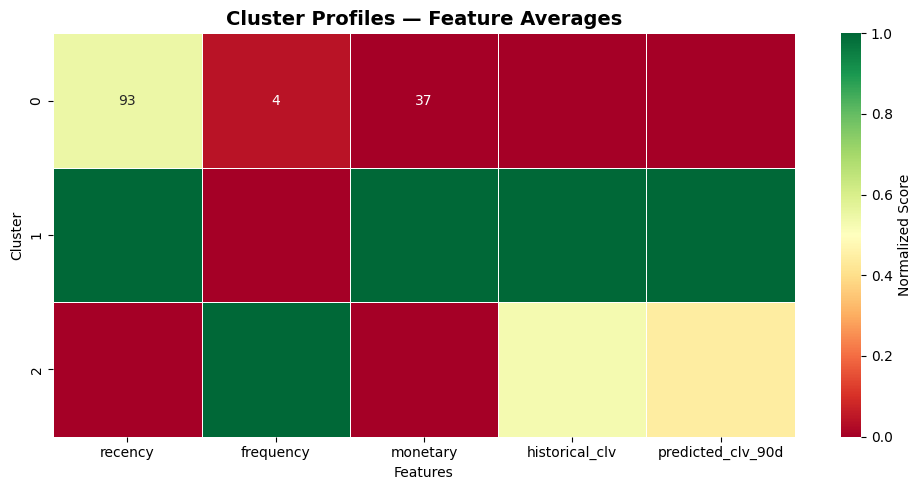

In [69]:
# Visualize cluster profiles as a heatmap
plt.figure(figsize=(10, 5))

# Normalize for heatmap visualization
cluster_profile_normalized = (cluster_profile - cluster_profile.min()) / \
                              (cluster_profile.max() - cluster_profile.min())

sns.heatmap(cluster_profile_normalized,
            annot=cluster_profile.values,
            fmt='.0f',
            cmap='RdYlGn',
            linewidths=0.5,
            cbar_kws={'label': 'Normalized Score'})

plt.title('Cluster Profiles — Feature Averages', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [70]:
#cluster_profile, map clusters to business names
# Based on actual profile analysis:
# Cluster 0: Recency=92d,  Freq=3.9x,  AOV=£36.91,    Hist CLV=£288    → At Risk
# Cluster 1: Recency=163d, Freq=1.5x,  AOV=£66,670,   Hist CLV=£24,565 → Champions
# Cluster 2: Recency=6d,   Freq=63x,   AOV=£188,      Hist CLV=£13,174 → Loyal Customers

def name_cluster(row):
    # Highest historical CLV + highest monetary value = Champions
    if row['historical_clv'] == cluster_profile['historical_clv'].max():
        return 'Champions'
    # Most recent + highest frequency = Loyal Customers
    elif row['recency'] == cluster_profile['recency'].min():
        return 'Loyal Customers'
    # Highest recency (longest inactive) + lowest CLV = At Risk
    elif row['recency'] == cluster_profile['recency'].max():
        return 'At Risk'

# Better approach — map by cluster number after reviewing profiles
cluster_names = {
    0: 'At Risk',          # Recency=92d,  low frequency, lowest CLV
    1: 'Champions',        # Recency=163d, highest AOV £66k, highest historical CLV
    2: 'Loyal Customers'   # Recency=6d,   highest frequency 63x, consistent buyers
}

# Apply names
final_df['cluster_name'] = final_df['cluster'].map(cluster_names)

print("=== CLUSTER SIZES ===")
print(final_df['cluster_name'].value_counts())

=== CLUSTER SIZES ===
cluster_name
At Risk            3896
Loyal Customers      22
Champions             2
Name: count, dtype: int64
